# NLP Engineering - Module 1 - Lesson 1 - Level Up: Preprocessing

## What's Different from the Original?

| Step               | Original (NLTK)                                 | Level Up (spaCy)                         |
| ------------------ | ----------------------------------------------- | ---------------------------------------- |
| Tokenization       | `TweetTokenizer`                                | `spaCy` pipeline                         |
| Stop words         | `nltk.corpus.stopwords`                         | `spaCy` built-in                         |
| Word normalization | **Stemming** (PorterStemmer) → `happi`, `sunni` | **Lemmatization** → `happy`, `sunny`     |
| Visualization      | Pie chart only                                  | Pie chart + **Word frequency bar chart** |

**Key upgrade:** Lemmatization returns _real dictionary words_, while stemming just chops off suffixes and can produce non-words.


## Setup

Install spaCy and download the English model if not already installed.


In [3]:
# Install spaCy and English model (run once)
import subprocess, sys

try:
    import spacy

    spacy.load("en_core_web_sm")
    print("spaCy and en_core_web_sm already installed.")
except (ImportError, OSError):
    print("Installing spaCy...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "spacy"])
    print("Downloading en_core_web_sm model...")
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
    print("Done!")


spaCy and en_core_web_sm already installed.


In [4]:
import re
import string
import random
from collections import Counter

import spacy
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import twitter_samples
from nltk.stem import PorterStemmer  # kept for comparison only
from nltk.tokenize import TweetTokenizer  # kept for comparison only
from nltk.corpus import stopwords

# Download NLTK data (needed for dataset + comparison)
nltk.download("twitter_samples", quiet=True)
nltk.download("stopwords", quiet=True)

# Load spaCy English model
nlp = spacy.load("en_core_web_sm")

print("All libraries loaded successfully!")


All libraries loaded successfully!


## Load the Twitter Dataset


In [5]:
all_positive_tweets = twitter_samples.strings("positive_tweets.json")
all_negative_tweets = twitter_samples.strings("negative_tweets.json")

print("Positive tweets:", len(all_positive_tweets))
print("Negative tweets:", len(all_negative_tweets))


Positive tweets: 5000
Negative tweets: 5000


## Dataset Distribution — Pie Chart


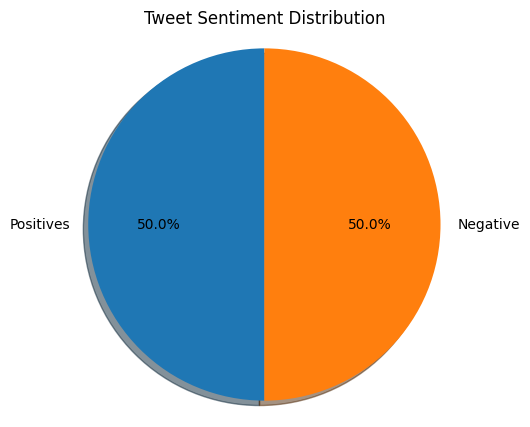

In [6]:
fig = plt.figure(figsize=(5, 5))
labels = "Positives", "Negative"
sizes = [len(all_positive_tweets), len(all_negative_tweets)]
plt.pie(sizes, labels=labels, autopct="%1.1f%%", shadow=True, startangle=90)
plt.axis("equal")
plt.title("Tweet Sentiment Distribution")
plt.show()


## Sample Tweet

We'll use the same tweet from the original lab so we can compare results directly.


In [7]:
tweet = all_positive_tweets[2277]
print("Original tweet:")
print(tweet)


Original tweet:
My beautiful sunflowers on a sunny Friday morning off :) #sunflowers #favourites #happy #Friday off… https://t.co/3tfYom0N1i


## Step 1 — Clean Raw Text (same as original)

We still use regex to remove URLs, retweet marks, and hashtag symbols — this part doesn't change.


In [8]:
def clean_tweet(tweet):
    """Remove RT markers, URLs, and hashtag symbols."""
    tweet = re.sub(r"^RT[\s]+", "", tweet)  # remove retweet text
    tweet = re.sub(r"https?://[^\s\n\r]+", "", tweet)  # remove URLs
    tweet = re.sub(r"#", "", tweet)  # remove # symbol only
    return tweet


tweet_cleaned = clean_tweet(tweet)
print(tweet_cleaned)


My beautiful sunflowers on a sunny Friday morning off :) sunflowers favourites happy Friday off… 


## Step 2 — spaCy Tokenization + Lemmatization

Instead of NLTK's `TweetTokenizer` + `PorterStemmer`, we run spaCy's full pipeline.

spaCy gives us:

- `token.text` — the original word
- `token.lemma_` — the **lemma** (dictionary base form)
- `token.is_stop` — whether it's a stop word
- `token.is_punct` — whether it's punctuation


In [9]:
doc = nlp(tweet_cleaned.lower())

print(f"{'Token':<15} {'Lemma':<15} {'Stop?':<8} {'Punct?'}")
print("-" * 50)
for token in doc:
    print(
        f"{token.text:<15} {token.lemma_:<15} {str(token.is_stop):<8} {token.is_punct}"
    )


Token           Lemma           Stop?    Punct?
--------------------------------------------------
my              my              True     False
beautiful       beautiful       False    False
sunflowers      sunflower       False    False
on              on              True     False
a               a               True     False
sunny           sunny           False    False
friday          friday          False    False
morning         morning         False    False
off             off             True     False
:)              :)              False    True
sunflowers      sunflower       False    False
favourites      favourite       False    False
happy           happy           False    False
friday          friday          False    False
off             off             True     False
…               …               False    True


## Step 3 — Remove Stop Words, Punctuation & Whitespace

Using spaCy's built-in flags instead of NLTK's stopwords list.


In [10]:
tokens_clean = [
    token.lemma_
    for token in doc
    if not token.is_stop  # remove stop words
    and not token.is_punct  # remove punctuation
    and not token.is_space  # remove whitespace tokens
    and token.lemma_.strip()  # remove empty strings
]

print("Processed tokens (lemmas):")
print(tokens_clean)


Processed tokens (lemmas):
['beautiful', 'sunflower', 'sunny', 'friday', 'morning', 'sunflower', 'favourite', 'happy', 'friday']


## Side-by-Side Comparison: NLTK Stemming vs spaCy Lemmatization

This is the most important difference. Stemming chops word endings aggressively — it's fast but produces non-words. Lemmatization looks up the actual base form in a dictionary.


In [11]:
# NLTK pipeline (from original lab)
stopwords_english = stopwords.words("english")
tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
stemmer = PorterStemmer()

nltk_tokens = tokenizer.tokenize(tweet_cleaned)
nltk_filtered = [
    w for w in nltk_tokens if w not in stopwords_english and w not in string.punctuation
]
nltk_stemmed = [stemmer.stem(w) for w in nltk_filtered]

# Print comparison
print(f"{'Original':<18} {'NLTK Stem':<18} {'spaCy Lemma'}")
print("-" * 55)

# Align using zip on filtered words
doc_filtered = [
    t
    for t in doc
    if not t.is_stop and not t.is_punct and not t.is_space and t.lemma_.strip()
]

max_len = max(len(nltk_filtered), len(doc_filtered))
for i in range(max_len):
    orig = nltk_filtered[i] if i < len(nltk_filtered) else "-"
    stemmed = nltk_stemmed[i] if i < len(nltk_stemmed) else "-"
    lemma = doc_filtered[i].lemma_ if i < len(doc_filtered) else "-"
    print(f"{orig:<18} {stemmed:<18} {lemma}")


Original           NLTK Stem          spaCy Lemma
-------------------------------------------------------
beautiful          beauti             beautiful
sunflowers         sunflow            sunflower
sunny              sunni              sunny
friday             friday             friday
morning            morn               morning
:)                 :)                 sunflower
sunflowers         sunflow            favourite
favourites         favourit           happy
happy              happi              friday
friday             friday             -
…                  …                  -


## Bonus: Word Frequency Bar Chart

Let's process all positive tweets with spaCy and visualize the **top 15 most common words**. This gives us a quick sense of the vocabulary that drives positive sentiment.


In [12]:
def preprocess_spacy(tweet, nlp):
    """Full preprocessing pipeline using spaCy."""
    tweet = clean_tweet(tweet)
    doc = nlp(tweet.lower())
    return [
        token.lemma_
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.is_space
        and len(token.lemma_) > 1  # skip single characters
    ]


# Process all positive tweets (use nlp.pipe for speed)
print("Processing all positive tweets with spaCy...")
all_pos_words = []
for tweet in all_positive_tweets:
    all_pos_words.extend(preprocess_spacy(tweet, nlp))

print(f"Total words after preprocessing: {len(all_pos_words)}")


Processing all positive tweets with spaCy...
Total words after preprocessing: 29409


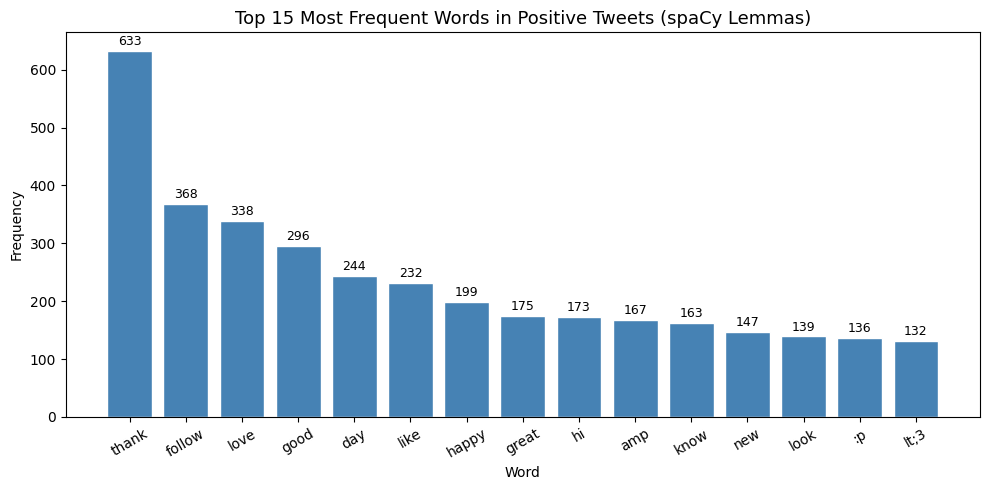

In [13]:
# Top 15 most frequent words
word_freq = Counter(all_pos_words)
top_words = word_freq.most_common(15)

words, counts = zip(*top_words)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(words, counts, color="steelblue", edgecolor="white")

# Add count labels on top of each bar
for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(count),
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_title(
    "Top 15 Most Frequent Words in Positive Tweets (spaCy Lemmas)", fontsize=13
)
ax.set_xlabel("Word")
ax.set_ylabel("Frequency")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


## Reusable `process_tweet_spacy()` Function

Equivalent to the original `process_tweet()` from `utils.py`, but using spaCy.


In [14]:
def process_tweet_spacy(tweet, nlp):
    """
    Preprocess a tweet using spaCy.
    Steps: clean → tokenize → remove stopwords/punct → lemmatize
    Returns a list of lemma strings.
    """
    tweet = clean_tweet(tweet)
    doc = nlp(tweet.lower())
    return [
        token.lemma_
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.is_space
        and len(token.lemma_) > 1
    ]


# Test it on our sample tweet
result = process_tweet_spacy(all_positive_tweets[2277], nlp)
print("Input: ", all_positive_tweets[2277])
print("Output:", result)


Input:  My beautiful sunflowers on a sunny Friday morning off :) #sunflowers #favourites #happy #Friday off… https://t.co/3tfYom0N1i
Output: ['beautiful', 'sunflower', 'sunny', 'friday', 'morning', 'sunflower', 'favourite', 'happy', 'friday']


## Summary

Here's what we upgraded:

- **spaCy replaces NLTK** for tokenization and stop word filtering — cleaner API, one unified pipeline
- **Lemmatization replaces Stemming** — produces real English words (`beautiful` stays `beautiful`, not `beauti`)
- **Word frequency chart** — added a bar chart to visualize which words dominate positive tweets
- **`process_tweet_spacy()`** — a drop-in upgrade for the original `process_tweet()` utility

The only thing we still use NLTK for is loading the `twitter_samples` dataset, since spaCy doesn't include datasets.
